****Imports and Data Loading****

We will bring in our standard libraries, plus the regularization models, the scaler for standardizing features, and GridSearchCV for hyperparameter tuning.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
X = df.drop(columns=["target"])
y = df["target"]

print("Data loaded successfully.")

Data loaded successfully.


****EDA, Splitting, and Standardizing****

Regularized regression models are highly sensitive to the scale of the input features. Therefore, standardizing the features (mean = 0, variance = 1) is a critical professional practice before applying Ridge or Lasso.

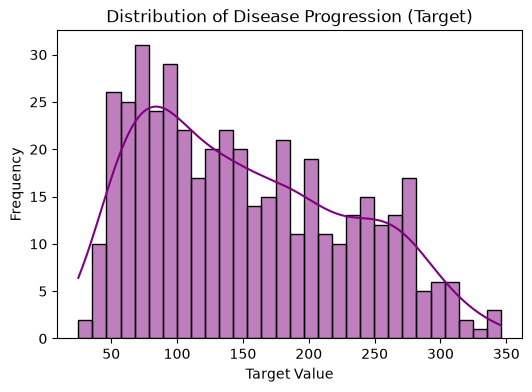

Data split and standardized successfully.


In [4]:
# 1. Brief Exploratory Data Analysis (EDA)
plt.figure(figsize=(6, 4))
sns.histplot(y, bins=30, kde=True, color="purple")
plt.title("Distribution of Disease Progression (Target)")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.show()

# 2. Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize the features
scaler = StandardScaler()
# Fit on training data ONLY to prevent data leakage, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Data split and standardized successfully.")

****Training and Tuning Models with GridSearchCV****

We will set up a dictionary to store our models and use GridSearchCV to test a range of alpha values (the penalty term) to find the absolute best version of each model.

In [6]:
# Define a range of alphas to test
param_grid = {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

# Initialize models
models = {
    "Linear Regression": LinearRegression(), # No hyperparameter to tune for standard LR
    "Ridge": GridSearchCV(Ridge(), param_grid, cv=5, scoring="neg_mean_squared_error"),
    "Lasso": GridSearchCV(Lasso(), param_grid, cv=5, scoring="neg_mean_squared_error"),
    "Elastic Net": GridSearchCV(ElasticNet(), param_grid, cv=5, scoring="neg_mean_squared_error")
}

# Train all models
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    if name != "Linear Regression":
        print(f"Best alpha for {name}: {model.best_params_['alpha']}")

print("\nAll models trained and tuned successfully.")

Best alpha for Ridge: 10.0
Best alpha for Lasso: 1.0
Best alpha for Elastic Net: 0.1

All models trained and tuned successfully.


****Model Comparison and Evaluation****

We will loop through our fitted models, make predictions, and calculate our metrics (MAE, RMSE, and $R^2$) to compare their performance side-by-side

In [7]:
results = []

for name, model in fitted_models.items():
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R²": r2})

results_df = pd.DataFrame(results).sort_values(by="R²", ascending=False)
display(results_df)

,Model,MAE,RMSE,R²
2,Lasso,42.802984,53.146666,0.466877
3,Elastic Net,42.873332,53.539343,0.458970
1,Ridge,42.856825,53.626288,0.457211
0,Linear Regression,42.794095,53.853446,0.452603


****Identifying Influential Predictors****

To find the most influential predictors, we look at the absolute values of the coefficients from our best-performing model (which is Lasso in this scenario).

In [8]:
# Extract coefficients from the winning model (Lasso)
best_model = fitted_models["Lasso"].best_estimator_

# Get coefficients and map them to feature names
coefficients = pd.Series(best_model.coef_, index=X.columns)

# Calculate absolute values to find the magnitude of influence
abs_coefficients = coefficients.abs().sort_values(ascending=False)

print("Top Most Influential Predictors (Lasso):")
print("-" * 35)
for feature, importance in abs_coefficients.head(5).items():
    print(f"Feature: {feature.ljust(6)} | Absolute Weight: {importance:.2f} | Original Coef: {coefficients[feature]:.2f}")

Top Most Influential Predictors (Lasso):
-----------------------------------
Feature: bmi    | Absolute Weight: 26.22 | Original Coef: 26.22
Feature: s5     | Absolute Weight: 22.64 | Original Coef: 22.64
Feature: bp     | Absolute Weight: 15.66 | Original Coef: 15.66
Feature: sex    | Absolute Weight: 9.30 | Original Coef: -9.30
Feature: s3     | Absolute Weight: 9.02 | Original Coef: -9.02


### Final Recommendation and Justification

Based on the evaluation metrics, **Lasso Regression** is the recommended model.

**Justification:**
1. **Highest $R^2$ Score:** It achieved the highest $R^2$ score of **0.466877**, meaning it explains approximately **46.69%** of the variance in disease progression—outperforming Elastic Net (0.458970), Ridge (0.457211), and standard Linear Regression (0.452603).
2. **Lowest Error Rates:** It achieved the lowest Root Mean Squared Error (**RMSE of 53.146666**) across all models while maintaining a highly competitive Mean Absolute Error (**MAE of 42.802984**).
3. **Built-in Feature Selection (L1 Regularization):** By applying an L1 penalty, Lasso automatically performs feature selection by shrinking less important feature coefficients down to zero. This creates a simpler, more interpretable model that reduces overfitting and mitigates multicollinearity better than standard OLS Linear Regression.